# Lesson 01 - Tensors, Vectors and Shapes

**Phase 0: Math Foundations** &nbsp;|&nbsp; Deep Learning From Scratch

> Represent data as numbers a network can eat, and never be confused by a shape again.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

A working understanding of the only data structure deep learning has: the
**tensor**. By the end of this notebook you will have implemented, in pure
Python with no imports, the five operations every framework is built on —
`shape`, `transpose`, `sum along an axis`, `dot product`, and
`broadcasting` — and checked them against NumPy and TensorFlow.

**Why it exists**

A neural network cannot see a photograph, a sentence, or a spreadsheet row.
It only ever multiplies and adds numbers. So the very first job in deep
learning is *encoding*: turning whatever you have into a grid of numbers
with an agreed-upon meaning for each axis. That grid is a tensor. A
grayscale image becomes a 2-D grid of brightnesses; a batch of colour
images becomes a 4-D grid `(images, height, width, colour)`.

**What breaks without it**

Essentially everything, and it breaks in the same way every time:

```
ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0
```

Shape errors are the single most common thing that stops a beginner, and
they are not really errors about code — they are errors about *meaning*.
If you cannot say out loud what axis 1 of your array represents, you cannot
fix the bug. Today is about never being in that position.

There is a second, quieter failure too. Broadcasting will silently reshape
your data and give you a plausible-looking wrong answer with no error at
all. We will trigger that on purpose in section 9 so you recognise it.

## 2. From scratch: the maths

### 2.1 The ladder of ranks

A tensor is indexed by some number of integers. **How many integers you
need is the rank.**

| Rank | Name | Written | Example | Shape |
|---|---|---|---|---|
| 0 | scalar | $x$ | a learning rate, `0.01` | `()` |
| 1 | vector | $x_i$ | one house: `[area, rooms, age]` | `(3,)` |
| 2 | matrix | $X_{ij}$ | 100 houses × 3 features | `(100, 3)` |
| 3 | 3-tensor | $X_{ijk}$ | an RGB image | `(28, 28, 3)` |
| 4 | 4-tensor | $X_{ijkl}$ | a batch of RGB images | `(32, 28, 28, 3)` |

The **shape** is the tuple of how far each index can run. For
$X \in \mathbb{R}^{m \times n}$ the shape is `(m, n)`, index $i$ runs
$1 \dots m$ and $j$ runs $1 \dots n$.

> **The habit that prevents most bugs:** never say "a matrix of data".
> Say "**rows are samples, columns are features**". Every axis gets a noun.

### 2.2 Transpose

Transposing swaps the roles of the indices:

$$(X^{\top})_{ij} = X_{ji}$$

so a shape `(m, n)` becomes `(n, m)`. Rows become columns. This is how you
switch between "each row is a sample" and "each column is a sample" — two
conventions that both appear in textbooks, and mixing them up is a classic
source of silent wrongness.

### 2.3 Reduction along an axis

Summing **collapses one axis**, and it is worth reading the formula slowly,
because *the index you sum over is the one that disappears*:

$$\text{sum}_{\text{axis}=0}(X)_j = \sum_{i=1}^{m} X_{ij}
  \qquad\text{shape } (m,n) \rightarrow (n,)$$

$$\text{sum}_{\text{axis}=1}(X)_i = \sum_{j=1}^{n} X_{ij}
  \qquad\text{shape } (m,n) \rightarrow (m,)$$

With `rows = samples, columns = features`:

- `axis=0` sums **down** the rows → one number **per feature**
  (this is how you compute the mean of each feature)
- `axis=1` sums **across** the columns → one number **per sample**
  (this is how you total up each sample)

Mean is the same thing divided by the count:
$\mu_j = \frac{1}{m}\sum_i X_{ij}$.

### 2.4 The dot product

For two vectors of the same length $n$:

$$u \cdot v = \sum_{i=1}^{n} u_i v_i$$

Multiply elementwise, then add it all up. A rank-1 and a rank-1 go in, a
rank-0 comes out. **This single formula is the atom of deep learning** —
a neuron computes $w \cdot x + b$, and a matrix multiply (Lesson 02) is
just a grid of dot products. It also measures alignment:
$u \cdot v = \lVert u \rVert \lVert v \rVert \cos\theta$, so it is positive
when two vectors point the same way, zero when perpendicular.

### 2.5 Broadcasting

You constantly need to add a bias vector to every row of a matrix. Writing
a loop is slow and ugly, so frameworks **stretch** the smaller array. The
rule, applied to the shapes **right-aligned**:

```
    A     (2, 3)          A     (2, 3)
    b        (3,)   -->   b     (1, 3)   pad missing axes with 1 on the LEFT
    ---------------       ---------------
    out   (2, 3)          any axis of size 1 is STRETCHED to match
```

Two axes are compatible when they are **equal**, or when **one of them is 1**.
Otherwise it is an error. Formally, for $A \in \mathbb{R}^{m\times n}$ and
$b \in \mathbb{R}^{n}$:

$$(A \oplus b)_{ij} = A_{ij} + b_j$$

The same $b_j$ is reused for every row $i$ — nothing is actually copied in
memory, the framework just reads the same value repeatedly.

And the trap, which we will demonstrate:

```
    A     (2, 3)  +  b  (2,)   -->  ERROR      3 vs 2, incompatible
    A     (2, 3)  +  c  (2, 1) -->  (2, 3)     stretches the OTHER way
```

Those last two are the same data with different shapes, and they mean
completely different things.

## 3. Numerical: worked by hand

Everything below is computed on paper first. The code in sections 5–7 has
to reproduce these exact numbers, or the code is wrong.

Our matrix — **2 samples, 3 features**:

$$A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix}
  \qquad \text{shape } (2, 3)$$

### 3.1 Transpose

$(A^\top)_{ij} = A_{ji}$, so the entry at row 1, col 2 of $A^\top$ is the
entry at row 2, col 1 of $A$, which is $4$:

$$A^{\top} = \begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}
  \qquad \text{shape } (3, 2)$$

### 3.2 Sum along axis 0 — down the rows, one total per feature

Index $i$ (the row index) is the one being summed, so it vanishes and we
are left with 3 numbers:

$$\begin{aligned}
j=1:&\quad A_{11} + A_{21} = 1 + 4 = 5 \\
j=2:&\quad A_{12} + A_{22} = 2 + 5 = 7 \\
j=3:&\quad A_{13} + A_{23} = 3 + 6 = 9
\end{aligned}$$

$$\text{sum}_{\text{axis}=0}(A) = [\,5,\ 7,\ 9\,] \qquad \text{shape } (3,)$$

### 3.3 Sum along axis 1 — across the columns, one total per sample

Now $j$ vanishes and 2 numbers remain:

$$\begin{aligned}
i=1:&\quad 1 + 2 + 3 = 6 \\
i=2:&\quad 4 + 5 + 6 = 15
\end{aligned}$$

$$\text{sum}_{\text{axis}=1}(A) = [\,6,\ 15\,] \qquad \text{shape } (2,)$$

Sum over **everything**: $6 + 15 = 5 + 7 + 9 = 21$. Both routes agree, as
they must — a useful sanity check to run on your own code.

### 3.4 Mean along axis 0

Divide the axis-0 sums by $m = 2$:

$$\mu = \left[\tfrac{5}{2},\ \tfrac{7}{2},\ \tfrac{9}{2}\right]
      = [\,2.5,\ 3.5,\ 4.5\,]$$

### 3.5 Dot product

With $u = [1, 2, 3]$ and $v = [4, 5, 6]$:

$$u \cdot v = (1)(4) + (2)(5) + (3)(6) = 4 + 10 + 18 = 32$$

### 3.6 Broadcasting a row vector, $b = [10, 20, 30]$, shape `(3,)`

Right-align: `(2,3)` vs `(3,)` → pad to `(1,3)` → stretch axis 0 from 1 to
2. So $b$ is added **once per row**, the same values each time:

$$A \oplus b = \begin{bmatrix} 1+10 & 2+20 & 3+30 \\ 4+10 & 5+20 & 6+30 \end{bmatrix}
             = \begin{bmatrix} 11 & 22 & 33 \\ 14 & 25 & 36 \end{bmatrix}$$

### 3.7 Broadcasting a column vector, $c = [[100],[200]]$, shape `(2,1)`

Now it is axis **1** that has size 1, so it stretches from 1 to 3 and each
value is reused across its whole row:

$$A \oplus c = \begin{bmatrix} 101 & 102 & 103 \\ 204 & 205 & 206 \end{bmatrix}$$

Same six numbers in $A$, same two numbers in the added vector, completely
different result. Shape is meaning.

**Keep these eight results in view. Every implementation below is judged
against them.**

In [1]:
# Setup -- the only cell with imports.
import time

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

# The hand-computed truth from section 3. Nothing below is allowed to disagree.
TRUTH = {
    "A":           [[1, 2, 3], [4, 5, 6]],
    "A_T":         [[1, 4], [2, 5], [3, 6]],
    "sum_axis0":   [5, 7, 9],
    "sum_axis1":   [6, 15],
    "sum_all":     21,
    "mean_axis0":  [2.5, 3.5, 4.5],
    "dot":         32,
    "bcast_row":   [[11, 22, 33], [14, 25, 36]],
    "bcast_col":   [[101, 102, 103], [204, 205, 206]],
}
print("Hand-computed targets loaded:", ", ".join(TRUTH))

Hand-computed targets loaded: A, A_T, sum_axis0, sum_axis1, sum_all, mean_axis0, dot, bcast_row, bcast_col


## 4. Visualization

### 4.1 The ladder of ranks, drawn

Each panel adds one index. That is the whole idea.

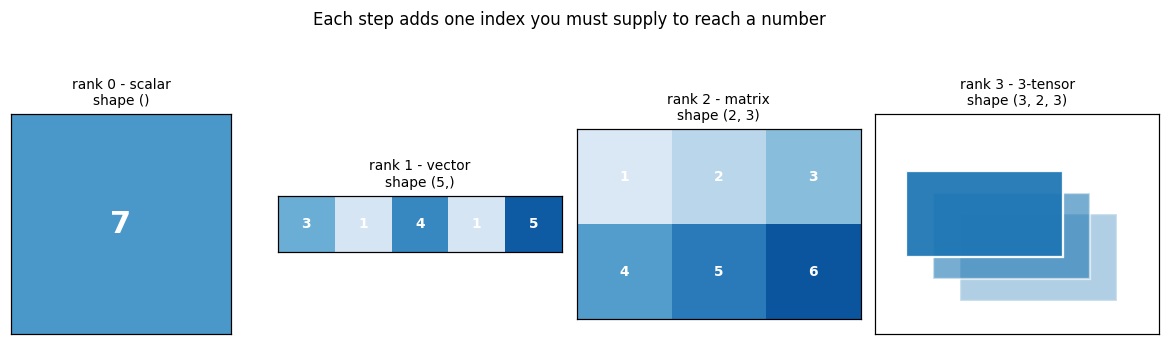

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))

# Rank 0 -- a scalar
axes[0].imshow([[0.6]], cmap="Blues", vmin=0, vmax=1)
axes[0].text(0, 0, "7", ha="center", va="center", fontsize=20, color="white", weight="bold")
axes[0].set_title("rank 0 - scalar\nshape ()", fontsize=9)

# Rank 1 -- a vector
vec = np.array([[3, 1, 4, 1, 5]])
axes[1].imshow(vec, cmap="Blues", vmin=0, vmax=6)
for j, v in enumerate(vec[0]):
    axes[1].text(j, 0, str(v), ha="center", va="center", color="white", weight="bold")
axes[1].set_title("rank 1 - vector\nshape (5,)", fontsize=9)

# Rank 2 -- a matrix
mat = np.array(TRUTH["A"])
axes[2].imshow(mat, cmap="Blues", vmin=0, vmax=7)
for i in range(2):
    for j in range(3):
        axes[2].text(j, i, str(mat[i, j]), ha="center", va="center", color="white", weight="bold")
axes[2].set_title("rank 2 - matrix\nshape (2, 3)", fontsize=9)

# Rank 3 -- stacked matrices, drawn as offset layers
axes[3].set_xlim(-0.5, 4.2); axes[3].set_ylim(3.4, -1.2)
for k, alpha in enumerate([0.35, 0.6, 0.95]):
    off = (2 - k) * 0.45
    axes[3].add_patch(plt.Rectangle((off, off), 2.6, 1.8, facecolor="#1f77b4",
                                    alpha=alpha, edgecolor="white", lw=1.5))
axes[3].set_title("rank 3 - 3-tensor\nshape (3, 2, 3)", fontsize=9)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle("Each step adds one index you must supply to reach a number", y=1.06)
plt.tight_layout()
plt.show()

### 4.2 What the two axes mean, and what reducing along each one does

This is the picture to memorise. `axis=0` collapses the **row** index, so
you get one number per column. `axis=1` collapses the **column** index, so
you get one number per row.

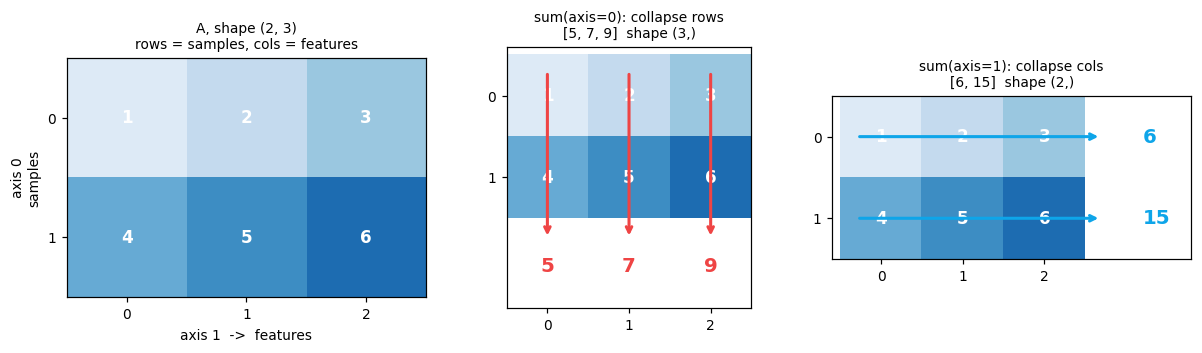

Sanity check -- both routes must reach the same grand total:
  sum(sum(axis=0)) = 21
  sum(sum(axis=1)) = 21


In [3]:
A = np.array(TRUTH["A"])
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(11, 3.2))

def draw_matrix(ax, M, title, cmap="Blues", vmax=None):
    ax.imshow(M, cmap=cmap, vmin=0, vmax=vmax if vmax else M.max() * 1.3)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:g}", ha="center", va="center",
                    color="white", weight="bold", fontsize=11)
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_title(title, fontsize=9); ax.grid(False)

draw_matrix(ax0, A, "A, shape (2, 3)\nrows = samples, cols = features")
ax0.set_xlabel("axis 1  ->  features"); ax0.set_ylabel("axis 0\nsamples")
ax0.annotate("", xy=(2.4, -0.7), xytext=(-0.4, -0.7),
             arrowprops=dict(arrowstyle="->", color="#0ea5e9", lw=2))
ax0.annotate("", xy=(-0.75, 1.4), xytext=(-0.75, -0.4),
             arrowprops=dict(arrowstyle="->", color="#ef4444", lw=2))

# axis=0 : sum DOWN the rows
draw_matrix(ax1, A, "sum(axis=0): collapse rows\n[5, 7, 9]  shape (3,)")
for j, s in enumerate(TRUTH["sum_axis0"]):
    ax1.annotate("", xy=(j, 1.75), xytext=(j, -0.3),
                 arrowprops=dict(arrowstyle="->", color="#ef4444", lw=2))
    ax1.text(j, 2.15, str(s), ha="center", color="#ef4444", weight="bold", fontsize=13)
ax1.set_ylim(2.6, -0.6)

# axis=1 : sum ACROSS the columns
draw_matrix(ax2, A, "sum(axis=1): collapse cols\n[6, 15]  shape (2,)")
for i, s in enumerate(TRUTH["sum_axis1"]):
    ax2.annotate("", xy=(2.7, i), xytext=(-0.3, i),
                 arrowprops=dict(arrowstyle="->", color="#0ea5e9", lw=2))
    ax2.text(3.2, i, str(s), va="center", color="#0ea5e9", weight="bold", fontsize=13)
ax2.set_xlim(-0.6, 3.8)

plt.tight_layout()
plt.show()

print("Sanity check -- both routes must reach the same grand total:")
print(f"  sum(sum(axis=0)) = {sum(TRUTH['sum_axis0'])}")
print(f"  sum(sum(axis=1)) = {sum(TRUTH['sum_axis1'])}")

### 4.3 Broadcasting, drawn

The same vector `[10, 20, 30]` reused down every row — versus a column
vector reused across every column.

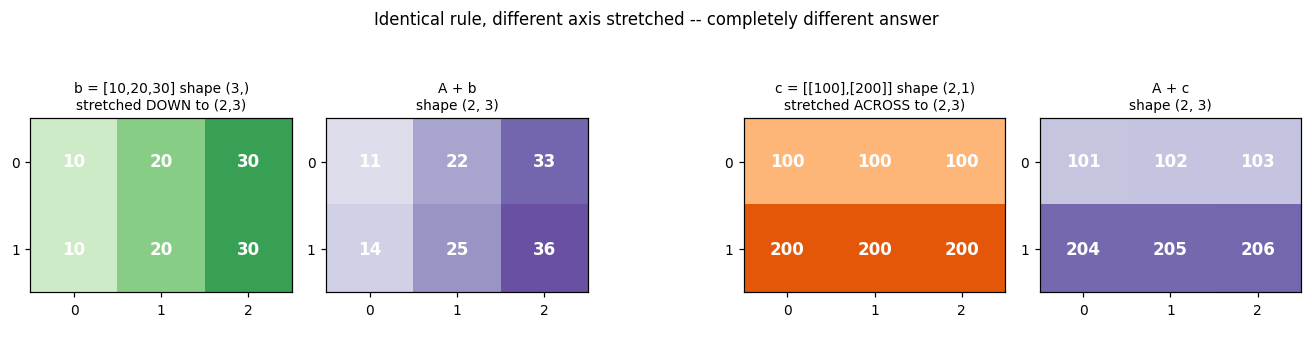

In [4]:
b = np.array([10, 20, 30])
c = np.array([[100], [200]])

fig, axes = plt.subplots(1, 5, figsize=(12, 2.8),
                         gridspec_kw={"width_ratios": [3, 3, 1, 3, 3]})

draw_matrix(axes[0], np.tile(b, (2, 1)), "b = [10,20,30] shape (3,)\nstretched DOWN to (2,3)",
            cmap="Greens", vmax=45)
draw_matrix(axes[1], np.array(TRUTH["bcast_row"]), "A + b\nshape (2, 3)", cmap="Purples", vmax=48)
axes[2].axis("off")
draw_matrix(axes[3], np.tile(c, (1, 3)), "c = [[100],[200]] shape (2,1)\nstretched ACROSS to (2,3)",
            cmap="Oranges", vmax=290)
draw_matrix(axes[4], np.array(TRUTH["bcast_col"]), "A + c\nshape (2, 3)", cmap="Purples", vmax=300)
for ax in axes:
    ax.grid(False)
plt.suptitle("Identical rule, different axis stretched -- completely different answer", y=1.08)
plt.tight_layout()
plt.show()

### 4.4 A real example: an image *is* a tensor

Nothing is downloaded — we draw a digit by hand into an 8×8 grid so you can
see the numbers and the picture side by side. This is exactly what MNIST
is, just at 28×28.

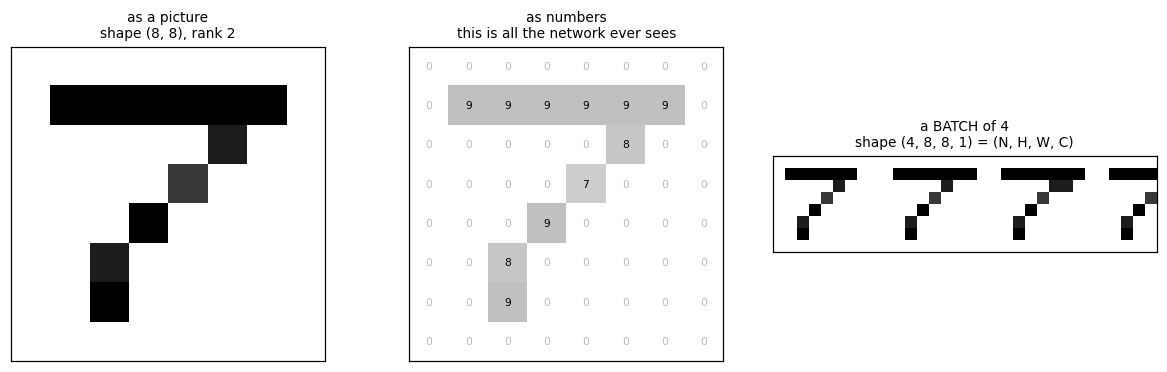

one image : (8, 8)  ->  (height, width)
a batch   : (4, 8, 8, 1)  ->  (batch, height, width, channels)
total numbers in the batch: 256

Every axis has a noun. Say them out loud and the shape errors stop.


In [5]:
digit7 = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 9, 9, 9, 9, 9, 9, 0],
    [0, 0, 0, 0, 0, 8, 0, 0],
    [0, 0, 0, 0, 7, 0, 0, 0],
    [0, 0, 0, 9, 0, 0, 0, 0],
    [0, 0, 8, 0, 0, 0, 0, 0],
    [0, 0, 9, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(11, 3.4))

ax0.imshow(digit7, cmap="gray_r")
ax0.set_title(f"as a picture\nshape {digit7.shape}, rank {digit7.ndim}", fontsize=9)

ax1.imshow(digit7, cmap="gray_r", alpha=0.25)
for i in range(8):
    for j in range(8):
        ax1.text(j, i, f"{digit7[i, j]:.0f}", ha="center", va="center", fontsize=7,
                 color="black" if digit7[i, j] else "#bbb")
ax1.set_title("as numbers\nthis is all the network ever sees", fontsize=9)

# A batch of 4 slightly-shifted copies -> rank 4, which is what you feed a CNN
batch = np.stack([np.roll(digit7, k, axis=1) for k in range(4)])[..., None]
ax2.imshow(np.concatenate([batch[k, :, :, 0] for k in range(4)], axis=1), cmap="gray_r")
ax2.set_title(f"a BATCH of 4\nshape {batch.shape} = (N, H, W, C)", fontsize=9)

for ax in (ax0, ax1, ax2):
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

print(f"one image : {digit7.shape}  ->  (height, width)")
print(f"a batch   : {batch.shape}  ->  (batch, height, width, channels)")
print(f"total numbers in the batch: {batch.size}")
print("\nEvery axis has a noun. Say them out loud and the shape errors stop.")

## 5. Scratch code — pure Python, no imports

Nested lists and loops only. Slow, but there is nowhere for magic to hide:
every index you see here is an index NumPy is also computing, just in C.

These must reproduce section 3 exactly.

In [6]:
def shape(t):
    """Rank and extent of a nested list, found by walking down axis 0."""
    dims = []
    while isinstance(t, list):
        dims.append(len(t))
        t = t[0] if t else None
    return tuple(dims)


def transpose(A):
    """(A^T)[i][j] = A[j][i]. Shape (m, n) -> (n, m)."""
    m, n = shape(A)
    return [[A[i][j] for i in range(m)] for j in range(n)]


def reduce_sum(A, axis=None):
    """Collapse one axis. The index summed over is the one that disappears."""
    m, n = shape(A)
    if axis is None:
        return sum(A[i][j] for i in range(m) for j in range(n))
    if axis == 0:                                     # sum over i -> n results
        return [sum(A[i][j] for i in range(m)) for j in range(n)]
    if axis == 1:                                     # sum over j -> m results
        return [sum(A[i][j] for j in range(n)) for i in range(m)]
    raise ValueError(f"axis {axis} out of range for a rank-2 tensor")


def reduce_mean(A, axis=0):
    m, n = shape(A)
    count = m if axis == 0 else n
    return [s / count for s in reduce_sum(A, axis)]


def dot(u, v):
    """u . v = sum_i u_i v_i -- the atom of deep learning."""
    if len(u) != len(v):
        raise ValueError(f"dot needs equal lengths, got {len(u)} and {len(v)}")
    return sum(u[i] * v[i] for i in range(len(u)))


def broadcast_add(A, B):
    """Add with NumPy's rule, spelled out: right-align, pad with 1s, stretch 1s."""
    sa, sb = shape(A), shape(B)
    # right-align by padding the SHORTER shape with 1s on the LEFT
    pad = max(len(sa), len(sb))
    sa_p = (1,) * (pad - len(sa)) + sa
    sb_p = (1,) * (pad - len(sb)) + sb

    out_shape = []
    for da, db in zip(sa_p, sb_p):
        if da != db and da != 1 and db != 1:
            raise ValueError(f"cannot broadcast {sa} with {sb}: {da} vs {db}")
        out_shape.append(max(da, db))

    def get(T, s_pad, i, j):
        """Read T at (i, j), reusing the value when that axis has size 1."""
        if len(s_pad) == 2 and len(shape(T)) == 2:
            return T[i if s_pad[0] > 1 else 0][j if s_pad[1] > 1 else 0]
        return T[j if s_pad[1] > 1 else 0]            # T was rank 1: only a column index

    m, n = out_shape
    return [[get(A, sa_p, i, j) + get(B, sb_p, i, j) for j in range(n)] for i in range(m)]


# --- run against the hand-computed numbers ------------------------------
A_s = [[1, 2, 3], [4, 5, 6]]
u_s, v_s = [1, 2, 3], [4, 5, 6]
b_s = [10, 20, 30]
c_s = [[100], [200]]

scratch = {
    "A":          A_s,
    "A_T":        transpose(A_s),
    "sum_axis0":  reduce_sum(A_s, 0),
    "sum_axis1":  reduce_sum(A_s, 1),
    "sum_all":    reduce_sum(A_s),
    "mean_axis0": reduce_mean(A_s, 0),
    "dot":        dot(u_s, v_s),
    "bcast_row":  broadcast_add(A_s, b_s),
    "bcast_col":  broadcast_add(A_s, c_s),
}

print(f"shape(A)        = {shape(A_s)}")
for k, v in scratch.items():
    ok = "OK " if v == TRUTH[k] else "XX "
    print(f"  {ok} {k:<11} = {v}")

assert scratch == TRUTH, "scratch implementation disagrees with the hand calculation"
print("\nPure Python reproduces every hand-computed number in section 3.")

shape(A)        = (2, 3)
  OK  A           = [[1, 2, 3], [4, 5, 6]]
  OK  A_T         = [[1, 4], [2, 5], [3, 6]]
  OK  sum_axis0   = [5, 7, 9]
  OK  sum_axis1   = [6, 15]
  OK  sum_all     = 21
  OK  mean_axis0  = [2.5, 3.5, 4.5]
  OK  dot         = 32
  OK  bcast_row   = [[11, 22, 33], [14, 25, 36]]
  OK  bcast_col   = [[101, 102, 103], [204, 205, 206]]

Pure Python reproduces every hand-computed number in section 3.


## 6. NumPy — vectorized

Identical maths, no visible loops. NumPy stores the numbers in one flat
block of memory and moves the looping into compiled C — typically 10–100x
faster, and the reason nobody ships the code in section 5.

In [7]:
A_np = np.array([[1, 2, 3], [4, 5, 6]])
u_np, v_np = np.array([1, 2, 3]), np.array([4, 5, 6])
b_np = np.array([10, 20, 30])
c_np = np.array([[100], [200]])

numpy_res = {
    "A":          A_np.tolist(),
    "A_T":        A_np.T.tolist(),
    "sum_axis0":  A_np.sum(axis=0).tolist(),
    "sum_axis1":  A_np.sum(axis=1).tolist(),
    "sum_all":    int(A_np.sum()),
    "mean_axis0": A_np.mean(axis=0).tolist(),
    "dot":        int(np.dot(u_np, v_np)),
    "bcast_row":  (A_np + b_np).tolist(),
    "bcast_col":  (A_np + c_np).tolist(),
}

for k, v in numpy_res.items():
    ok = "OK " if v == TRUTH[k] else "XX "
    print(f"  {ok} {k:<11} = {v}")

assert numpy_res == TRUTH
print("\nNumPy matches too.")

  OK  A           = [[1, 2, 3], [4, 5, 6]]
  OK  A_T         = [[1, 4], [2, 5], [3, 6]]
  OK  sum_axis0   = [5, 7, 9]
  OK  sum_axis1   = [6, 15]
  OK  sum_all     = 21
  OK  mean_axis0  = [2.5, 3.5, 4.5]
  OK  dot         = 32
  OK  bcast_row   = [[11, 22, 33], [14, 25, 36]]
  OK  bcast_col   = [[101, 102, 103], [204, 205, 206]]

NumPy matches too.


In [8]:
# The attributes worth knowing by heart, on a real 4-D batch.
print("For the batch of images from section 4.4:")
print(f"  .shape  {batch.shape}      how far each index runs")
print(f"  .ndim   {batch.ndim}                   the rank = len(shape)")
print(f"  .size   {batch.size}                 total numbers stored")
print(f"  .dtype  {batch.dtype}           how each number is stored")

# Reshape keeps every number and only reinterprets the grid: 4*8*8*1 == 256
flat = batch.reshape(4, -1)      # -1 means "work it out from the others"
print(f"\nflatten each image for a dense layer: {batch.shape} -> {flat.shape}")
print(f"  numbers preserved: {batch.size} == {flat.size}  ({batch.size == flat.size})")

# And the speed difference that justifies all of this
big = np.random.rand(200_000)
t0 = time.perf_counter(); py_sum = sum(float(x) for x in big); t1 = time.perf_counter()
t2 = time.perf_counter(); np_sum = big.sum();                   t3 = time.perf_counter()
print(f"\nsumming 200,000 numbers -- same answer ({abs(py_sum - np_sum) < 1e-6}):")
print(f"  pure Python {(t1 - t0) * 1000:7.2f} ms")
print(f"  NumPy       {(t3 - t2) * 1000:7.2f} ms   ~{(t1 - t0) / max(t3 - t2, 1e-9):.0f}x faster")

For the batch of images from section 4.4:
  .shape  (4, 8, 8, 1)      how far each index runs
  .ndim   4                   the rank = len(shape)
  .size   256                 total numbers stored
  .dtype  float64           how each number is stored

flatten each image for a dense layer: (4, 8, 8, 1) -> (4, 64)
  numbers preserved: 256 == 256  (True)

summing 200,000 numbers -- same answer (True):
  pure Python   13.44 ms
  NumPy          0.33 ms   ~41x faster


## 7. TensorFlow

Same operations again, in the framework you will actually ship with. Note
that `tf.reduce_sum` is named for what it does — *reduces* an axis away —
which is a clearer name than `sum`. On Kaggle TensorFlow is preinstalled;
locally this section skips itself if it is missing.

In [9]:
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [10]:
if HAS_TF:
    A_tf = tf.constant([[1, 2, 3], [4, 5, 6]])
    u_tf, v_tf = tf.constant([1, 2, 3]), tf.constant([4, 5, 6])
    b_tf = tf.constant([10, 20, 30])
    c_tf = tf.constant([[100], [200]])

    tf_res = {
        "A":          A_tf.numpy().tolist(),
        "A_T":        tf.transpose(A_tf).numpy().tolist(),
        "sum_axis0":  tf.reduce_sum(A_tf, axis=0).numpy().tolist(),
        "sum_axis1":  tf.reduce_sum(A_tf, axis=1).numpy().tolist(),
        "sum_all":    int(tf.reduce_sum(A_tf).numpy()),
        "mean_axis0": tf.reduce_mean(tf.cast(A_tf, tf.float32), axis=0).numpy().tolist(),
        "dot":        int(tf.tensordot(u_tf, v_tf, axes=1).numpy()),
        "bcast_row":  (A_tf + b_tf).numpy().tolist(),
        "bcast_col":  (A_tf + c_tf).numpy().tolist(),
    }

    for k, v in tf_res.items():
        ok = "OK " if v == TRUTH[k] else "XX "
        print(f"  {ok} {k:<11} = {v}")
    assert tf_res == TRUTH
    print("\nTensorFlow matches as well.")
else:
    tf_res = None

## 8. Agreement check

The lesson is only honest if hand-calculation, pure Python, NumPy and
TensorFlow all land on the same numbers.

In [11]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch, "numpy": numpy_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res

print(f"{'quantity':<12} " + " ".join(f"{n:>17}" for n in implementations))
print("-" * (13 + 18 * len(implementations)))
for key in TRUTH:
    cells = []
    for res in implementations.values():
        s = str(res[key])
        cells.append(f"{s if len(s) <= 17 else s[:14] + '...':>17}")
    print(f"{key:<12} " + " ".join(cells))

for name, res in implementations.items():
    assert res == TRUTH, f"{name} disagrees with the hand calculation"

skipped = "" if tf_res is not None else "  (tensorflow skipped -- not installed locally)"
print(f"\nAll implementations agree.{skipped}")

quantity      hand (section 3)           scratch             numpy
-------------------------------------------------------------------
A            [[1, 2, 3], [4... [[1, 2, 3], [4... [[1, 2, 3], [4...
A_T          [[1, 4], [2, 5... [[1, 4], [2, 5... [[1, 4], [2, 5...
sum_axis0            [5, 7, 9]         [5, 7, 9]         [5, 7, 9]
sum_axis1              [6, 15]           [6, 15]           [6, 15]
sum_all                     21                21                21
mean_axis0     [2.5, 3.5, 4.5]   [2.5, 3.5, 4.5]   [2.5, 3.5, 4.5]
dot                         32                32                32
bcast_row    [[11, 22, 33],... [[11, 22, 33],... [[11, 22, 33],...
bcast_col    [[101, 102, 10... [[101, 102, 10... [[101, 102, 10...

All implementations agree.  (tensorflow skipped -- not installed locally)


## 9. The silent failure — worth triggering once on purpose

Broadcasting does not always protect you. Sometimes it gives you a
perfectly shaped, completely wrong answer and no warning at all.

In [12]:
row = np.array([1, 2, 3])       # shape (3,)
col = np.array([[1], [2], [3]]) # shape (3, 1) -- the SAME three numbers

print(f"row.shape = {row.shape}   col.shape = {col.shape}")
print(f"\nrow + row -> shape {(row + row).shape}, which is what you wanted:\n{row + row}")
print(f"\nrow + col -> shape {(row + col).shape}, a 3x3 OUTER SUM you never asked for:\n{row + col}")
print("\nNo error. No warning. Just a silently wrong 9-element tensor where")
print("you expected 3. This is the bug that costs an afternoon.")

try:
    np.array([[1, 2, 3], [4, 5, 6]]) + np.array([1, 2])   # (2,3) + (2,) -> 3 vs 2
except ValueError as e:
    print(f"\nThe loud version, by contrast:\n  ValueError: {e}")

print("\nDefence: print .shape before and after every operation you are unsure of,")
print("and use keepdims=True when you reduce and intend to broadcast back:")
mu = A_np.mean(axis=0, keepdims=True)
print(f"  A.mean(axis=0)               -> shape {A_np.mean(axis=0).shape}")
print(f"  A.mean(axis=0, keepdims=True)-> shape {mu.shape}  <- safe to subtract from A")
print(f"  A - mu  -> shape {(A_np - mu).shape}, each feature now centred on zero")

row.shape = (3,)   col.shape = (3, 1)

row + row -> shape (3,), which is what you wanted:
[2 4 6]

row + col -> shape (3, 3), a 3x3 OUTER SUM you never asked for:
[[2 3 4]
 [3 4 5]
 [4 5 6]]

No error. No warning. Just a silently wrong 9-element tensor where
you expected 3. This is the bug that costs an afternoon.

The loud version, by contrast:
  ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

Defence: print .shape before and after every operation you are unsure of,
and use keepdims=True when you reduce and intend to broadcast back:
  A.mean(axis=0)               -> shape (3,)
  A.mean(axis=0, keepdims=True)-> shape (1, 3)  <- safe to subtract from A
  A - mu  -> shape (2, 3), each feature now centred on zero


## 10. Exercises

Work these out **on paper first**, then run the cell. Each `assert` tells
you when you got it right. Solutions are in `solutions/01-*.ipynb` — but
the learning is in the paper, not the answer.

In [13]:
# --- Exercise 1 -------------------------------------------------------
# What is the shape of a batch of 64 colour photos, 128 px wide, 96 px tall,
# in (batch, height, width, channels) order? Give it as a tuple.
ex1_shape = None        # <-- your answer, e.g. (1, 2, 3, 4)

assert ex1_shape == (64, 96, 128, 3), "height comes before width; RGB is 3 channels"
print("Ex 1 OK -- how many numbers is that in total?", 64 * 96 * 128 * 3)

AssertionError: height comes before width; RGB is 3 channels

In [14]:
# --- Exercise 2 -------------------------------------------------------
# M has shape (5, 4). Give the shape of each result, without running NumPy.
ex2 = {
    "M.T":                None,   # transpose
    "M.sum(axis=0)":      None,   # collapse the row index
    "M.sum(axis=1)":      None,   # collapse the column index
    "M.sum(axis=0, keepdims=True)": None,   # collapse but KEEP the axis, as size 1
}

assert ex2 == {"M.T": (4, 5), "M.sum(axis=0)": (4,),
               "M.sum(axis=1)": (5,), "M.sum(axis=0, keepdims=True)": (1, 4)}
M = np.arange(20).reshape(5, 4)
print("Ex 2 OK -- verified:", M.T.shape, M.sum(axis=0).shape,
      M.sum(axis=1).shape, M.sum(axis=0, keepdims=True).shape)

AssertionError: 

In [15]:
# --- Exercise 3 -------------------------------------------------------
# Implement cosine similarity in PURE PYTHON using only your dot() function.
#     cos(u, v) = (u . v) / (|u| |v|),  where |u| = sqrt(u . u)
# No imports -- x ** 0.5 is a square root.
def cosine_similarity(u, v):
    return None     # <-- your code


assert cosine_similarity([1, 0], [1, 0]) == 1.0                  # same direction
assert cosine_similarity([1, 0], [0, 1]) == 0.0                  # perpendicular
assert cosine_similarity([1, 0], [-1, 0]) == -1.0                # opposite
assert abs(cosine_similarity([1, 2, 3], [4, 5, 6]) - 0.9746318) < 1e-6
print("Ex 3 OK -- this is how embeddings get compared in Lesson 29.")

AssertionError: 

In [16]:
# --- Exercise 4 -------------------------------------------------------
# Standardize each FEATURE (column) to mean 0, std 1 -- the preprocessing
# step in front of nearly every network. Use keepdims so it broadcasts.
X = np.array([[1.0, 100.0], [2.0, 200.0], [3.0, 300.0], [4.0, 400.0]])   # (4, 2)

def standardize(X):
    return None     # <-- your code: (X - mean over samples) / std over samples


Z = standardize(X)
assert Z is not None and Z.shape == (4, 2)
assert np.allclose(Z.mean(axis=0), [0, 0], atol=1e-9), "each column must average 0"
assert np.allclose(Z.std(axis=0), [1, 1], atol=1e-9), "each column must have std 1"
assert np.allclose(Z[:, 0], Z[:, 1]), "both columns held the same pattern at different scale"
print("Ex 4 OK -- two wildly different scales, now directly comparable:\n", Z)

AssertionError: 

In [17]:
# --- Exercise 5 -------------------------------------------------------
# Predict the output shape of each broadcast. Write "error" if it fails.
ex5 = {
    ((3, 1), (1, 4)):  None,
    ((2, 3), (3,)):    None,
    ((2, 3), (2,)):    None,
    ((5, 1, 4), (3, 4)): None,
}

assert ex5 == {((3, 1), (1, 4)): (3, 4), ((2, 3), (3,)): (2, 3),
               ((2, 3), (2,)): "error", ((5, 1, 4), (3, 4)): (5, 3, 4)}
print("Ex 5 OK -- you can now read a broadcast without running it.")

AssertionError: 

In [18]:
# --- Exercise 6 (stretch) --------------------------------------------
# Extend the pure-Python reduce_sum to rank-3 nested lists, for any of the
# three axes. Check against NumPy on a random tensor.
def reduce_sum3(T, axis):
    return None     # <-- your code


T = np.random.randint(0, 9, (2, 3, 4))
T_list = T.tolist()
for ax in (0, 1, 2):
    got = reduce_sum3(T_list, ax)
    assert got is not None and np.array_equal(np.array(got), T.sum(axis=ax)), f"axis {ax} wrong"
print("Ex 6 OK -- you have now written the core of a tensor library.")

AssertionError: axis 0 wrong

## 11. What you learned

- **Rank is how many integers you need** to reach a single number; shape is
  how far each of those integers runs.
- **Every axis deserves a noun.** "Rows are samples, columns are features"
  turns cryptic shape errors into sentences you can reason about.
- **Reducing along an axis deletes that axis.** `axis=0` collapses rows and
  leaves one number per feature; `axis=1` collapses columns and leaves one
  per sample. Two ways to reach the grand total, and they must agree.
- **The dot product $\sum_i u_i v_i$ is the atom.** A neuron is
  $w \cdot x + b$; everything else is arrangement.
- **Broadcasting right-aligns shapes, pads with 1s, stretches the 1s.** It
  saves you loops, and it will silently hand you an outer product if you
  get a shape wrong. `keepdims=True` is the seatbelt.
- Pure Python, NumPy and TensorFlow computed **identical numbers**; NumPy
  was orders of magnitude faster. That gap is the entire reason frameworks
  exist — not different maths, just different execution.

### Next

**Lesson 02 — Matrix Multiplication by Hand.** We arrange dot products into
a grid, compute a full matmul on paper, and find out why the inner
dimensions must match. That is the operation a GPU is built to do, and the
operation a neural network layer *is*.